# Tugas - Klasifikasi dengan Support Vector Machine (SVM)

|          Nama          |    NRP     |
|------------------------|------------|
| Muhammad Fardan Hafidz | 5054251021 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model SVM Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja SVM secara praktik, khususnya:
1. Perbedaan hasil antara kernel Linear dan kernel RBF
2. Pengaruh parameter `C` dan `gamma` terhadap gejala overfitting/underfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model SVM dengan kernel Linear dan kernel RBF.
   - Lakukan eksperimen regularisasi dengan variasi nilai `C` dan `gamma`.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")


In [2]:
df = pd.read_csv('data.csv')
df.info()
display(df.head())
display(df.describe())
display(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

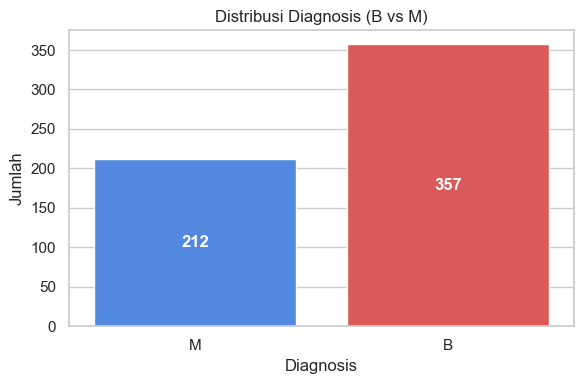

In [3]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='diagnosis', data=df, palette=['#3b82f6', '#ef4444'])
plt.title('Distribusi Diagnosis (B vs M)')
plt.xlabel('Diagnosis')
plt.ylabel('Jumlah')
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout()
plt.show()


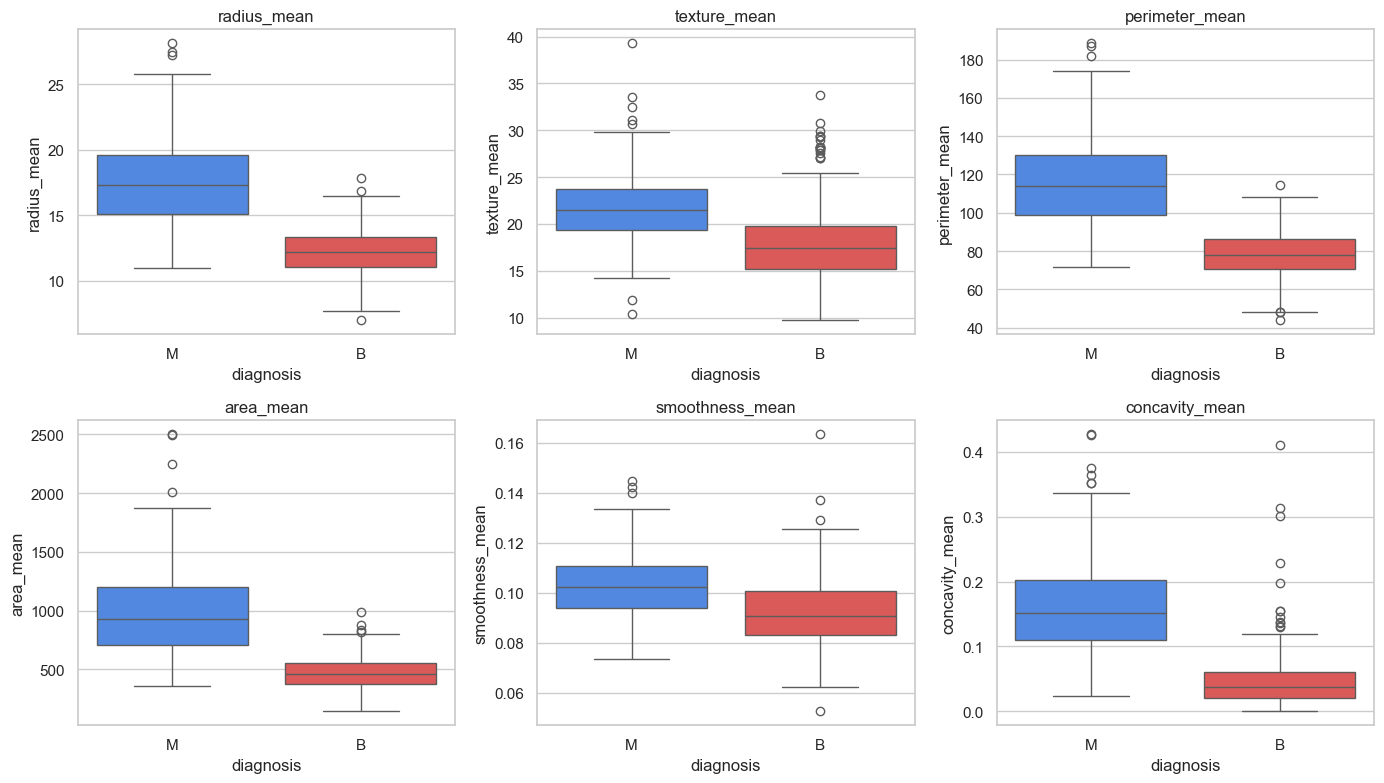

In [4]:
key_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'concavity_mean']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, col in enumerate(key_features):
    sns.boxplot(x='diagnosis', y=col, data=df, ax=axes[idx], palette=['#3b82f6', '#ef4444'])
    axes[idx].set_title(col)

plt.tight_layout()
plt.show()


## Exploratory Data Analysis (EDA)
- Kolom `id` dan `Unnamed: 32` (seluruhnya NaN) tidak digunakan untuk pemodelan.
- Fitur seperti `radius_mean`, `perimeter_mean`, dan `area_mean` menunjukkan perbedaan sebaran yang jelas antara kelas Benign dan Malignant.
- Variasi skala antar fitur cukup besar, sehingga membutuhkan feature scaling.


# 2. Preprocessing

In [5]:
df_cleaned = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')
df_cleaned.isnull().sum()


diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [6]:
df_cleaned['diagnosis'] = df_cleaned['diagnosis'].map({'B': 0, 'M': 1})
df_cleaned.head()


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
X = df_cleaned.drop(columns=['diagnosis'])
y = df_cleaned['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train.shape, X_test.shape


((455, 30), (114, 30))

**Catatan penting:** SVM adalah algoritma berbasis jarak (margin dihitung dari posisi antar titik data), sehingga sangat sensitif terhadap skala fitur. Fitur dengan rentang nilai besar bisa mendominasi perhitungan jarak meskipun sebenarnya tidak lebih penting. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 3. Eksperimen Model

## 3.1 SVM dengan Kernel Linear

Kernel Linear mencari hyperplane pemisah berupa garis/bidang lurus, tanpa proyeksi ke dimensi yang lebih tinggi. Cocok digunakan sebagai baseline, terutama jika dari hasil EDA data terlihat cukup terpisah secara linear.

In [9]:
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train_scaled, y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [10]:
y_pred_linear = svm_linear.predict(X_test_scaled)
print(classification_report(y_test, y_pred_linear, target_names=['B', 'M']))


              precision    recall  f1-score   support

           B       0.95      1.00      0.97        72
           M       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



## 3.2 SVM dengan Kernel RBF

Kernel RBF (Radial Basis Function) memproyeksikan data ke ruang berdimensi lebih tinggi melalui kernel trick, sehingga mampu menangani batas keputusan yang non-linear.

In [11]:
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [12]:
y_pred_rbf = svm_rbf.predict(X_test_scaled)
print(classification_report(y_test, y_pred_rbf, target_names=['B', 'M']))


              precision    recall  f1-score   support

           B       0.96      1.00      0.98        72
           M       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



## 3.3 Eksperimen Regularisasi: Pengaruh C dan Gamma terhadap Overfitting

Parameter `C` mengatur trade-off antara margin lebar dan toleransi kesalahan klasifikasi, sedangkan `gamma` (khusus kernel RBF) mengatur seberapa lokal pengaruh tiap titik data. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai `C` (dan/atau `gamma`) memengaruhi akurasi training dan testing.

In [13]:
C_values = [0.01, 0.1, 1, 10, 100]
models_c = [SVC(kernel='rbf', C=c, gamma='scale', random_state=42).fit(X_train_scaled, y_train) for c in C_values]


In [14]:
train_acc_list = [accuracy_score(y_train, m.predict(X_train_scaled)) for m in models_c]
test_acc_list = [accuracy_score(y_test, m.predict(X_test_scaled)) for m in models_c]

df_c_results = pd.DataFrame({
    'C': C_values,
    'Train Accuracy': train_acc_list,
    'Test Accuracy': test_acc_list
})
df_c_results


,C,Train Accuracy,Test Accuracy
0,0.01,0.626374,0.631579
1,0.10,0.953846,0.947368
2,1.00,0.986813,0.973684
3,10.00,0.989011,0.973684
4,100.00,1.000000,0.964912


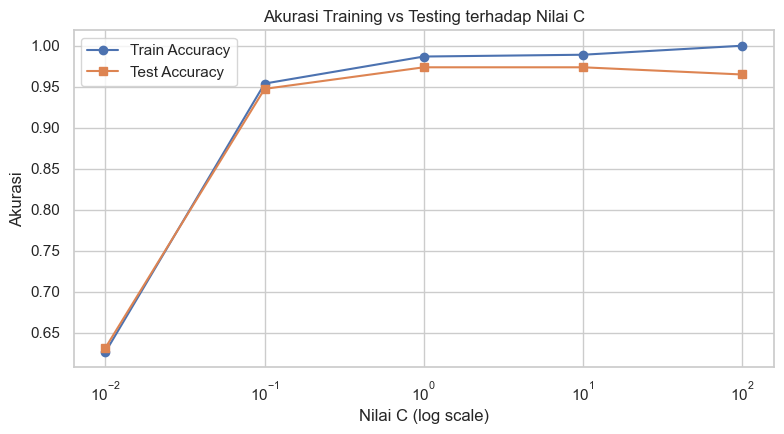

In [15]:
plt.figure(figsize=(8, 4.5))
plt.plot(C_values, train_acc_list, marker='o', label='Train Accuracy')
plt.plot(C_values, test_acc_list, marker='s', label='Test Accuracy')
plt.xscale('log')
plt.title('Akurasi Training vs Testing terhadap Nilai C')
plt.xlabel('Nilai C (log scale)')
plt.ylabel('Akurasi')
plt.legend()
plt.tight_layout()
plt.show()


# 4. Evaluasi Model

In [16]:
def get_metrics(y_true, y_pred, name):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

pd.DataFrame([
    get_metrics(y_test, y_pred_linear, 'SVM Linear'),
    get_metrics(y_test, y_pred_rbf, 'SVM RBF')
])


,Model,Accuracy,Precision,Recall,F1-Score
0,SVM Linear,0.964912,1.0,0.904762,0.950000
1,SVM RBF,0.973684,1.0,0.928571,0.962963


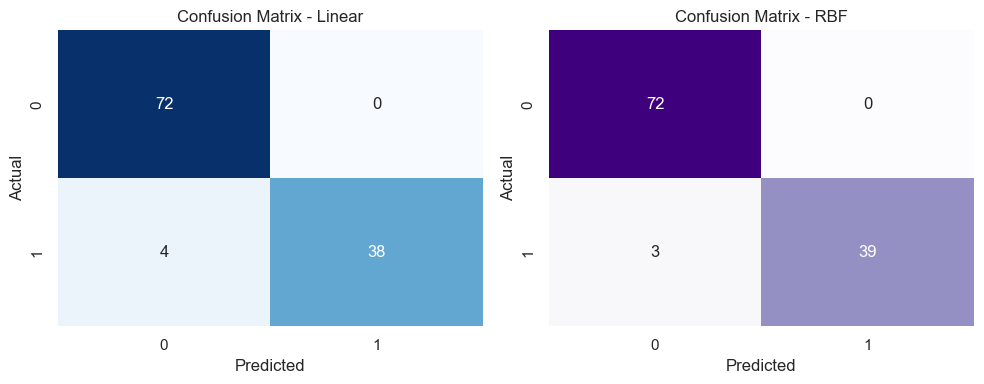

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_linear), annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix - Linear')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_pred_rbf), annot=True, fmt='d', cmap='Purples', ax=axes[1], cbar=False)
axes[1].set_title('Confusion Matrix - RBF')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


In [18]:
pd.DataFrame({
    'Model': ['SVM Linear', 'SVM RBF'],
    'Support Vectors B': [svm_linear.n_support_[0], svm_rbf.n_support_[0]],
    'Support Vectors M': [svm_linear.n_support_[1], svm_rbf.n_support_[1]],
    'Total Support Vectors': [sum(svm_linear.n_support_), sum(svm_rbf.n_support_)]
})


,Model,Support Vectors B,Support Vectors M,Total Support Vectors
0,SVM Linear,19,19,38
1,SVM RBF,50,57,107


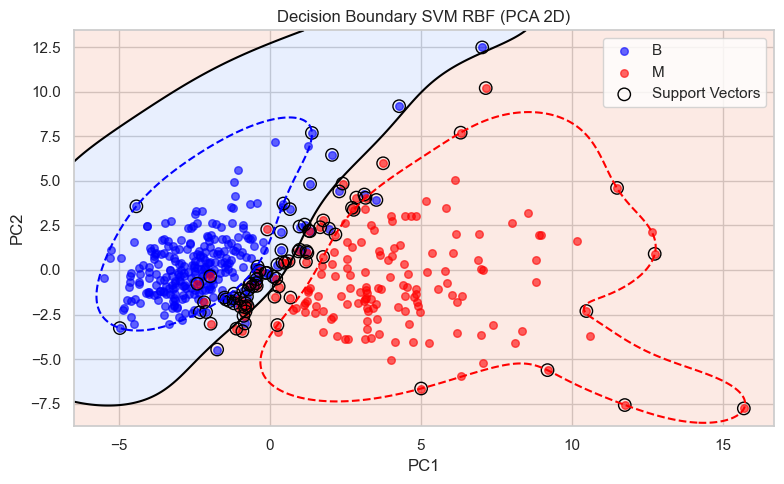

In [19]:
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

svm_pca = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42).fit(X_train_pca, y_train)

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))
Z = svm_pca.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 5))
plt.contourf(xx, yy, Z > 0, alpha=0.2, cmap='coolwarm')
plt.contour(xx, yy, Z, levels=[-1, 0, 1], linestyles=['--', '-', '--'], colors=['blue', 'black', 'red'])
plt.scatter(X_train_pca[y_train == 0, 0], X_train_pca[y_train == 0, 1], c='blue', label='B', alpha=0.6, s=30)
plt.scatter(X_train_pca[y_train == 1, 0], X_train_pca[y_train == 1, 1], c='red', label='M', alpha=0.6, s=30)
plt.scatter(svm_pca.support_vectors_[:, 0], svm_pca.support_vectors_[:, 1], s=80, facecolors='none', edgecolors='black', label='Support Vectors')
plt.title('Decision Boundary SVM RBF (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()


# 5. Analisis

### Analisis Hasil Eksperimen

1. **Performa Kernel Linear vs RBF:**
   - Kedua model memberikan akurasi tinggi (Linear: 96.49%, RBF: 97.37%).
   - Fitur utama pada EDA sudah menunjukkan pemisahan yang cukup linear, sehingga kernel Linear sudah sangat kuat. Kernel RBF sedikit lebih unggul karena fleksibel menangani titik data yang tumpang tindih di sekitar batas margin.

2. **Pengaruh Parameter Regularisasi C:**
   - Nilai $C = 0.01$ menyebabkan **underfitting** (akurasi train ~62.6%, test ~63.2%) karena margin terlalu lebar dan toleransi error terlalu besar.
   - Nilai $C = 1.0$ hingga $10.0$ merupakan titik **optimal** (akurasi test 97.37%).
   - Pada $C = 100.0$, terlihat gejala **overfitting** di mana akurasi train mencapai 100% namun akurasi test menurun menjadi 96.49% akibat margin yang terlalu sempit.

3. **Jumlah Support Vectors:**
   - Model Linear menggunakan 38 support vectors, sedangkan RBF menggunakan 107 support vectors.
   - Jumlah support vector yang lebih banyak pada RBF menunjukkan batas keputusan yang lebih kompleks dibandingkan hyperplane datar pada kernel Linear.


# 6. Kesimpulan dan Saran

### Kesimpulan dan Saran

**Kesimpulan:**
- SVM efektif untuk klasifikasi data kanker payudara dengan akurasi di atas 96%.
- Kernel RBF ($C=1.0$) menghasilkan performa terbaik (akurasi 97.37%).
- Parameter $C$ terbukti mengendalikan trade-off bias-variance: $C$ terlalu kecil memicu underfitting, sedangkan $C$ terlalu besar memicu overfitting.
- Model Linear lebih sederhana dengan jumlah support vector yang jauh lebih sedikit.

**Saran:**
- Melakukan hyperparameter tuning gabungan untuk $C$ dan $\gamma$ dengan GridSearchCV.
- Menguji parameter `class_weight='balanced'` untuk meminimalkan false negative pada diagnosis medis.
